# Financial Market Analysis in Python

This project compares several financial assets using Python.  
The goal is to analyse return, risk, volatility, drawdown, and risk-adjusted performance.

Assets analysed:

- Apple
- Nvidia
- Tesla
- Bitcoin
- S&P 500
- Gold

In [1]:
!pip install yfinance


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
tickers = ["AAPL", "NVDA", "TSLA", "BTC-USD", "^GSPC", "GC=F"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

data.head()


[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-01,NaN,7200.174316,NaN,NaN,NaN,NaN
2020-01-02,72.333893,6985.470215,1524.500000,5.963803,28.684,3257.850098
2020-01-03,71.630638,7344.884277,1549.199951,5.868348,29.534,3234.850098
2020-01-04,NaN,7410.656738,NaN,NaN,NaN,NaN
2020-01-05,NaN,7411.317383,NaN,NaN,NaN,NaN


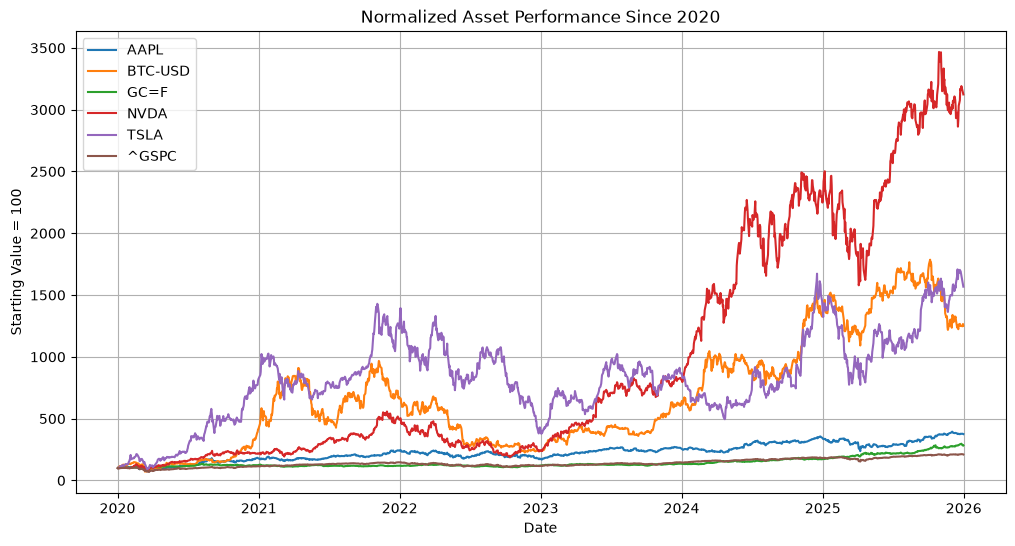

In [4]:
data = data.dropna()

normalized_data = data / data.iloc[0] * 100

plt.figure(figsize=(12, 6))

for ticker in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[ticker], label=ticker)

plt.title("Normalized Asset Performance Since 2020")
plt.xlabel("Date")
plt.ylabel("Starting Value = 100")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
daily_returns = data.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Date,,,,,,
2020-01-03,-0.009722,0.051452,0.016202,-0.016006,0.029633,-0.007060
2020-01-06,0.007968,0.057773,0.010973,0.004194,0.019255,0.003533
2020-01-07,-0.004703,0.050774,0.003576,0.012107,0.038801,-0.002803
2020-01-08,0.016086,-0.010269,-0.009161,0.001875,0.049205,0.004902
2020-01-09,0.021241,-0.024851,-0.003660,0.010983,-0.021945,0.006655


In [6]:
total_returns = (data.iloc[-1] / data.iloc[0] - 1) * 100

total_returns.sort_values(ascending=False)

Ticker
NVDA       3023.389346
TSLA       1467.842703
BTC-USD    1152.726380
AAPL        275.143414
GC=F        183.738937
^GSPC       110.123234
dtype: float64

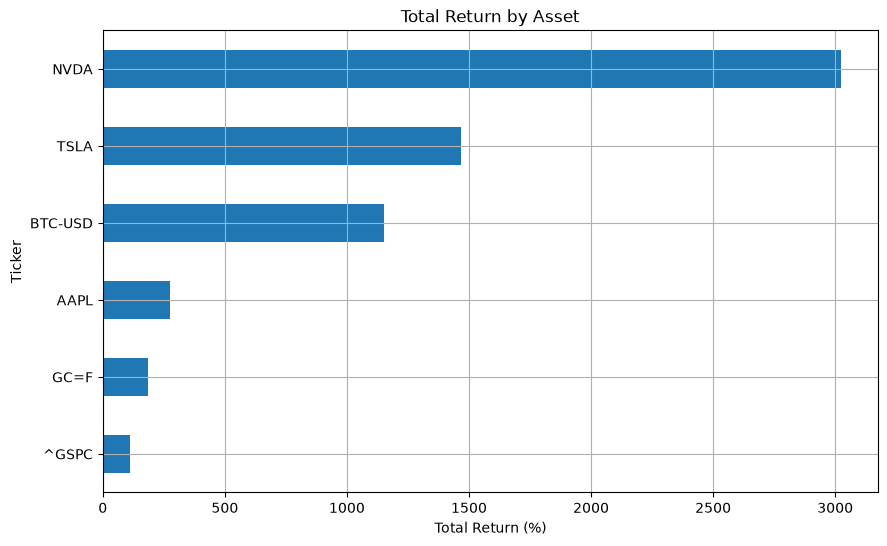

In [7]:
plt.figure(figsize=(10, 6))

total_returns.sort_values().plot(kind="barh")

plt.title("Total Return by Asset")
plt.xlabel("Total Return (%)")
plt.grid(True)
plt.show()

In [8]:
annual_volatility = daily_returns.std() * np.sqrt(252) * 100

annual_volatility.sort_values(ascending=False)

Ticker
TSLA       66.570910
BTC-USD    61.392742
NVDA       53.184871
AAPL       31.809486
^GSPC      20.927113
GC=F       17.076323
dtype: float64

In [9]:
annual_return = daily_returns.mean() * 252 * 100

annual_return.sort_values(ascending=False)

Ticker
NVDA       71.650775
TSLA       68.111946
BTC-USD    61.486644
AAPL       27.158880
GC=F       18.904882
^GSPC      14.615983
dtype: float64

In [10]:
sharpe_ratio = annual_return / annual_volatility

sharpe_ratio.sort_values(ascending=False)

Ticker
NVDA       1.347202
GC=F       1.107081
TSLA       1.023149
BTC-USD    1.001530
AAPL       0.853798
^GSPC      0.698423
dtype: float64

In [11]:
cumulative_returns = (1 + daily_returns).cumprod()

running_max = cumulative_returns.cummax()

drawdown = (cumulative_returns / running_max - 1) * 100

max_drawdown = drawdown.min()

max_drawdown.sort_values()

Ticker
BTC-USD   -76.634564
TSLA      -73.632217
NVDA      -66.335093
^GSPC     -33.924960
AAPL      -33.360520
GC=F      -20.872530
dtype: float64

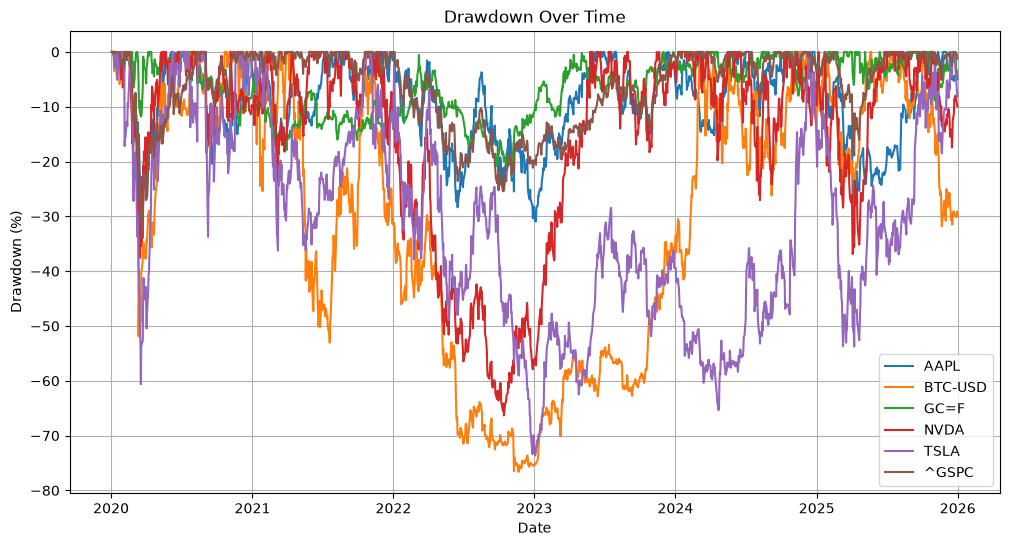

In [12]:
plt.figure(figsize=(12, 6))

for ticker in drawdown.columns:
    plt.plot(drawdown.index, drawdown[ticker], label=ticker)

plt.title("Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "Annual Return (%)": annual_return,
    "Annual Volatility (%)": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown (%)": max_drawdown
})

summary = summary.sort_values("Sharpe Ratio", ascending=False)

summary

,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Maximum Drawdown (%)
Ticker,,,,,
NVDA,3023.389346,71.650775,53.184871,1.347202,-66.335093
GC=F,183.738937,18.904882,17.076323,1.107081,-20.872530
TSLA,1467.842703,68.111946,66.570910,1.023149,-73.632217
BTC-USD,1152.726380,61.486644,61.392742,1.001530,-76.634564
AAPL,275.143414,27.158880,31.809486,0.853798,-33.360520
^GSPC,110.123234,14.615983,20.927113,0.698423,-33.924960


## Conclusion

This project compared Apple, Nvidia, Tesla, Bitcoin, the S&P 500, and gold using historical price data.

The analysis focused on:

- Total return
- Annual return
- Annual volatility
- Sharpe ratio
- Maximum drawdown

The asset with the highest total return was: Nvidia (NVDA), with a total return of about 3023%.

The asset with the highest volatility was: Tesla (TSLA), with annual volatility of about 66.6%.

The asset with the best Sharpe ratio was: Nvidia (NVDA), with a Sharpe ratio of about 1.35.

The asset with the worst maximum drawdown was: Bitcoin (BTC-USD), with a maximum drawdown of about -76.6%.

Overall, this project helped me practise Python, pandas, NumPy, matplotlib, financial data analysis, and basic risk-return analysis.

## Correlation Matrix

This section analyses how closely the assets move together.  
Correlation helps show whether assets tend to rise and fall at the same time.

A correlation close to 1 means two assets move very similarly.  
A correlation close to 0 means they do not have a strong relationship.  
A negative correlation means they often move in opposite directions.

In [14]:
correlation_matrix = daily_returns.corr()

correlation_matrix

Ticker,AAPL,BTC-USD,GC=F,NVDA,TSLA,^GSPC
Ticker,,,,,,
AAPL,1.000000,0.287257,0.075229,0.578635,0.490057,0.782932
BTC-USD,0.287257,1.000000,0.107505,0.312661,0.307112,0.375433
GC=F,0.075229,0.107505,1.000000,0.080892,0.060148,0.106131
NVDA,0.578635,0.312661,0.080892,1.000000,0.475249,0.702086
TSLA,0.490057,0.307112,0.060148,0.475249,1.000000,0.527827
^GSPC,0.782932,0.375433,0.106131,0.702086,0.527827,1.000000


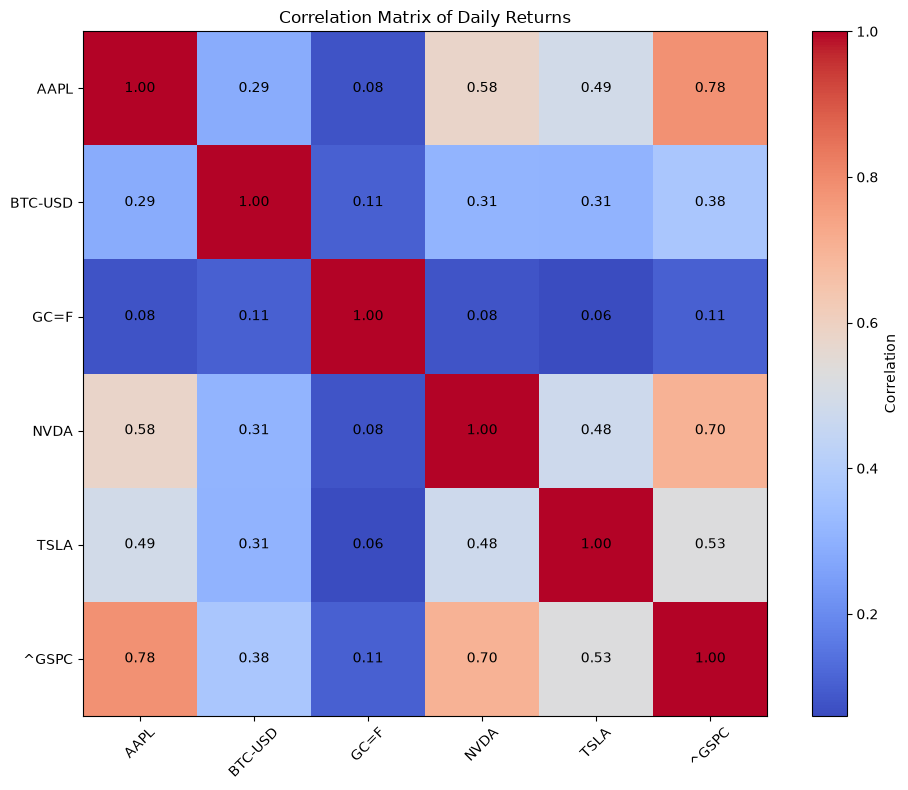

In [15]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix of Daily Returns")

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## Equal-Weight Portfolio

This section creates a simple portfolio where each asset has the same weight.

The goal is to compare the performance of a diversified portfolio against individual assets.

This model assumes the portfolio is rebalanced to equal weights each trading day. Transaction costs, taxes, and a non-zero risk-free rate are not included.

In [16]:
portfolio_returns = daily_returns.mean(axis=1)

portfolio_cumulative = (1 + portfolio_returns).cumprod() * 100

portfolio_cumulative.head()

Date
2020-01-03    101.074981
2020-01-06    102.821831
2020-01-07    104.496974
2020-01-08    105.413744
2020-01-09    105.210349
dtype: float64

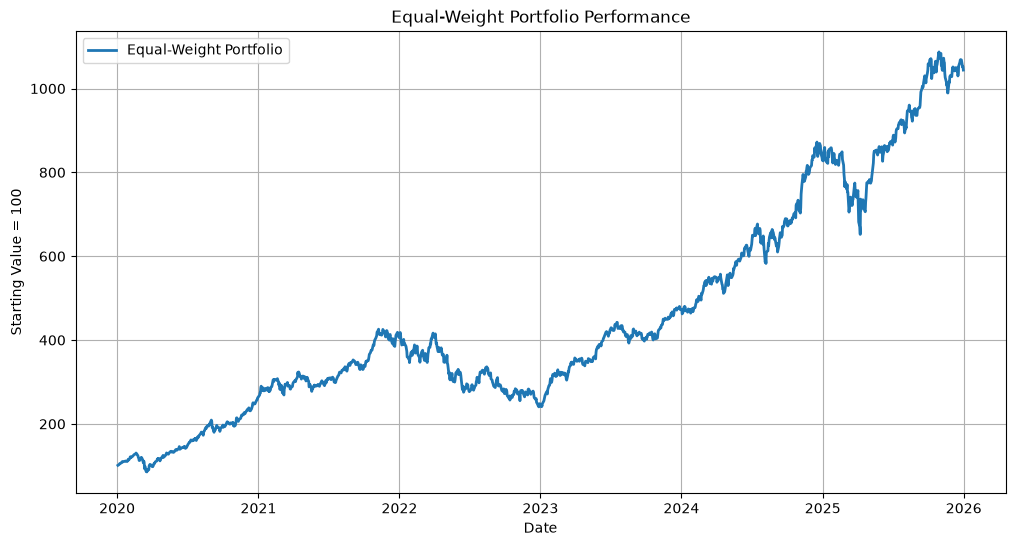

In [17]:
plt.figure(figsize=(12, 6))

plt.plot(portfolio_cumulative.index, portfolio_cumulative, label="Equal-Weight Portfolio", linewidth=2)

plt.title("Equal-Weight Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Starting Value = 100")
plt.legend()
plt.grid(True)
plt.show()

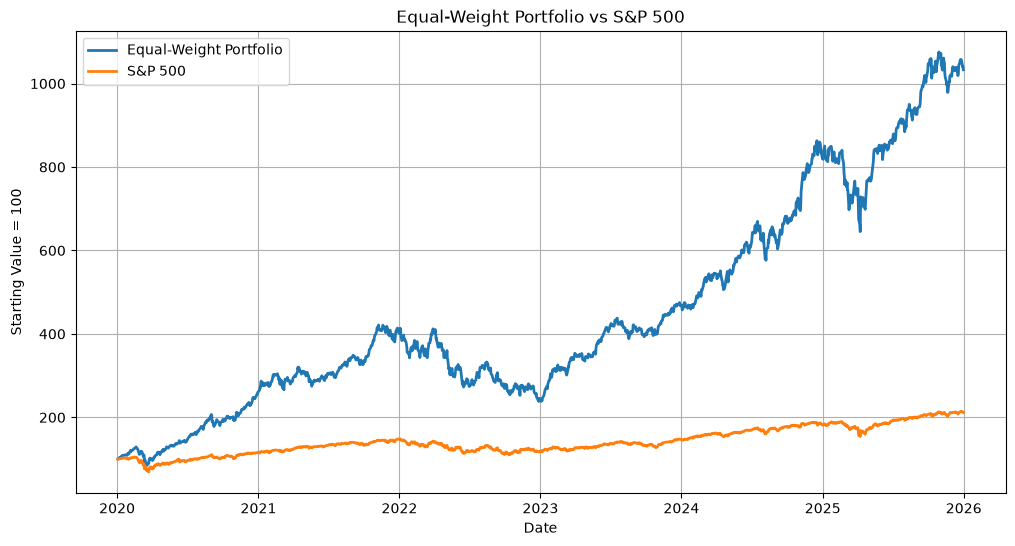

In [18]:
comparison = pd.DataFrame({
    "Equal-Weight Portfolio": portfolio_cumulative,
    "S&P 500": normalized_data["^GSPC"]
}).dropna()

# Make both series start at exactly 100 on the same date
comparison = comparison / comparison.iloc[0] * 100

plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison["Equal-Weight Portfolio"],
    label="Equal-Weight Portfolio",
    linewidth=2
)

plt.plot(
    comparison.index,
    comparison["S&P 500"],
    label="S&P 500",
    linewidth=2
)

plt.title("Equal-Weight Portfolio vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Starting Value = 100")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
portfolio_total_return = ((1 + portfolio_returns).prod() - 1) * 100
portfolio_annual_return = portfolio_returns.mean() * 252 * 100
portfolio_annual_volatility = portfolio_returns.std() * np.sqrt(252) * 100
portfolio_sharpe_ratio = portfolio_annual_return / portfolio_annual_volatility

portfolio_cumulative_returns = (1 + portfolio_returns).cumprod()
portfolio_running_max = portfolio_cumulative_returns.cummax()
portfolio_drawdown = (portfolio_cumulative_returns / portfolio_running_max - 1) * 100
portfolio_max_drawdown = portfolio_drawdown.min()

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total Return (%)",
        "Annual Return (%)",
        "Annual Volatility (%)",
        "Sharpe Ratio",
        "Maximum Drawdown (%)"
    ],
    "Equal-Weight Portfolio": [
        portfolio_total_return,
        portfolio_annual_return,
        portfolio_annual_volatility,
        portfolio_sharpe_ratio,
        portfolio_max_drawdown
    ]
})

portfolio_summary

,Metric,Equal-Weight Portfolio
0,Total Return (%),944.112653
1,Annual Return (%),43.654852
2,Annual Volatility (%),29.604194
3,Sharpe Ratio,1.474617
4,Maximum Drawdown (%),-43.496770


## Version 2 Conclusion

In Version 2, I added a correlation matrix and an equal-weight portfolio.

The correlation matrix helped show how strongly the assets moved together.

The equal-weight portfolio showed how combining different assets can reduce dependence on one single asset and create a more diversified investment profile.

This upgrade helped me practise correlation analysis, portfolio construction, diversification, and financial data visualisation.